In [1]:
import numpy as np
import mmcfilters
import matplotlib
import math

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (16,16)

from IPython import display
from os import listdir
import cv2 as cv


In [35]:
#imgInput = cv.imread("../dat/imgTeste.png", cv.IMREAD_GRAYSCALE)
imgInput = cv.imread("../dat/imgObjetos.png", cv.IMREAD_GRAYSCALE)
#imgInput = cv.imread("../dat/cable.png", cv.IMREAD_GRAYSCALE)
#imgInput = cv.imread("../dat/images/peppers_gray.tif", cv.IMREAD_GRAYSCALE)

(num_rows, num_cols) = imgInput.shape


imgInput = np.array([
[203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203],
[203,203,203, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78,203,203,203,203,203,203,203,203],
[203,203, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78,203,203,203,203,203,203,203],
[203,203, 78, 78,126,126,126,126,126,126,126, 78, 78, 78, 78, 78, 78, 78,203,203,203, 54, 54,203,203],
[203,203, 78, 78,126, 38, 38, 38,126,126,126, 78, 78, 78, 78, 78, 78, 78,203,203, 54, 54, 54, 54,203],
[203,203, 78, 78,126, 38, 38, 38,126,126,126, 78, 78, 78, 78, 78, 78, 78,203, 54, 54, 54, 80, 54,203],
[203,203, 78, 78,126, 38, 38, 38,126, 78, 78, 78, 78, 78, 78, 78, 78, 78,203, 54, 80, 54, 54, 54,203],
[203, 78, 78, 78,126, 38, 38,126,126, 78, 78, 78,203,203,203,203,203,203,203, 54, 54, 54, 54,203,203],
[203, 78, 78, 78,126,126,126,126, 78, 78,203,203,203,203,203,203,203,203, 54, 54, 54, 54, 54,203,203],
[203, 78, 78, 78,126,126,126, 78, 78, 78,203,203,253,253,253,203,203,203, 54, 80, 54, 54, 54,203,203],
[203, 78, 78, 78,126,126,126, 78, 78, 78,203,203,253,253,253,203,203, 54, 54, 54, 54, 54,203,203,203],
[203, 78, 78, 78,126,126,126, 78, 78, 78,203,203,253,253,253,203,203,203, 54, 54, 54,203,203,203,203],
[203, 78, 78, 78,126,126,126, 78, 78, 78, 78,203,203,203,203,203,203,203,203,203,203,203,203,203,203],
[203, 78, 78, 78,126,126,126, 78, 78, 78, 78,203,203,203,126,126,126,126,203,203,203,203,203,203,203],
[203, 78, 78, 78,126,126,126, 78, 78, 78, 78,203,203,126,126,126,126,126,126,126,126,126,203,203,203],
[203, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78,203,203,126,126,126,126,126,126, 72,126,126,203,203,203],
[203, 78, 78, 78, 78, 78, 78,161,161,161, 78, 78,203,126,126,126,126,126,126, 72, 72,126,126,126,203],
[203, 78, 78, 78, 78, 78,161,161,161,161,161, 78,203,126,126,126,126,126, 72, 72, 72,126,126,126,203],
[203, 78, 78, 78, 78, 78,161, 30, 30, 30,161, 78,203,203,126,126,126, 72, 72, 72, 72, 72,126,126,203],
[203, 78, 78, 78, 78, 78,161, 30, 90, 30,161, 78, 78,203,126,126, 72, 72, 72, 72, 72, 72, 72,126,203],
[203, 78, 78, 78, 78, 78,161, 30, 30, 30,161, 78, 78,203,203,126,126,126,126,126,126,126,126,126,203],
[203, 78, 78, 78, 78, 78,161,161,161,161,161, 78, 78, 78,203,203,126,126,126,126,126,126,126,203,203],
[203, 78, 78, 78, 78, 78,161,161,161,161,161, 78, 78, 78,203,203,203,203,126,126,126,126,203,203,203],
[203,203, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78,203,203,203,203,203,203,203,203,203,203],
[203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203]
])
(num_rows, num_cols) = imgInput.shape


In [43]:
imgInput = np.array([
    [6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,1,1,1,1,1,1,6,6,6,6,6,6,6,6,6,6,5,5,5,5,2,2,2,2,2,2,2,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,7,7,7,7,7,7,7,7,7],
    [6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,1,1,1,1,1,1,6,6,6,6,6,6,6,6,6,6,5,5,5,5,2,2,2,2,2,2,2,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,7,7,7,7,7,7,7,7,7],
    [6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,1,1,1,1,1,1,6,6,6,6,6,6,6,6,6,6,5,5,5,5,2,2,2,2,2,2,2,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,7,7,7,7,7,7,7,7,7],
    [6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,1,1,1,1,1,1,1,0,0,0,0,0,0,0,1,1,1,1,1,1,1,6,6,6,6,6,6,6,6,6,6,5,5,5,5,2,2,2,2,2,2,2,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,7,7,7,7,7,7,7,7,7],
    [6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,1,1,1,1,1,1,1,0,0,0,0,0,0,0,1,1,1,1,1,1,1,6,6,6,6,6,6,6,6,6,6,5,5,5,5,2,2,2,2,2,2,2,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,7,7,7,7,7,7,7,7,7],
    [6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,1,1,1,1,1,1,1,0,0,0,0,0,0,0,1,1,1,1,1,1,1,6,6,6,6,6,6,6,6,6,6,5,5,5,5,2,2,2,2,2,2,2,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,3,3,3,7,7,7,7,7,7],
    [6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,1,1,1,1,1,1,1,0,0,0,0,0,0,0,1,1,1,1,1,1,6,6,6,6,6,6,6,6,6,6,6,5,5,5,5,2,2,2,2,2,2,2,2,2,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,3,3,3,3,3,3,3,7,7],
    [6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,1,1,1,1,1,1,1,0,0,0,0,0,0,0,1,1,1,1,1,1,6,6,6,6,6,6,6,6,6,6,6,5,5,5,5,2,2,2,2,2,2,2,2,2,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,3,3,3,3,3,3,3,3,3],
    [6,6,6,6,6,6,6,1,1,1,1,1,1,6,6,6,6,6,6,1,1,1,1,1,1,1,0,0,0,0,0,0,0,1,1,1,1,1,1,6,6,6,6,6,6,6,6,6,6,5,5,5,5,5,2,2,2,2,2,2,2,2,2,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,3,3,3,3,3,3,3,3,3],
    [6,6,6,6,6,6,6,1,1,1,1,1,1,1,6,6,6,6,6,1,1,1,1,1,1,1,0,0,0,0,0,0,0,1,1,1,1,1,1,6,6,6,6,6,6,6,6,6,6,5,5,5,5,5,2,2,2,2,2,2,2,2,2,2,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,3,3,3,3,3,3,3,3,3],
    [6,6,6,6,6,6,6,1,1,1,1,1,1,1,6,6,6,6,6,1,1,1,1,1,1,1,0,0,0,0,0,0,0,1,1,1,1,1,1,6,6,6,6,6,6,6,6,6,6,5,5,5,5,5,2,2,2,2,2,2,2,2,2,2,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,3,3,3,3,3,3,3,3,3],
    [6,6,6,6,6,6,6,1,1,1,1,1,1,1,6,6,6,6,6,1,1,1,1,1,1,1,0,0,0,0,0,0,0,1,1,1,1,1,1,6,6,6,6,6,6,6,6,6,6,5,5,5,5,5,2,2,2,2,2,2,2,2,2,2,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,3,3,3,3,3,3,3,3,3],
    [6,6,6,6,6,6,6,1,1,1,1,1,1,1,6,6,6,6,6,1,1,1,1,1,1,0,0,0,0,0,0,0,0,1,1,1,1,1,1,5,5,5,5,6,1,1,1,1,1,5,5,5,5,5,2,2,2,2,2,2,2,2,2,2,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,3,3,3,3,3,3,3,3,3],
    [6,6,6,6,6,6,6,1,1,1,1,1,1,1,6,6,6,6,6,1,1,1,1,1,1,0,0,0,0,0,0,0,0,1,1,1,1,1,1,5,5,5,5,5,1,1,1,1,1,5,5,5,5,5,2,2,2,2,2,2,2,2,2,2,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,3,3,3,3,3,3,3,3,3],
    [6,6,6,6,6,6,6,1,4,4,4,4,4,6,6,6,6,6,6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,5,5,5,5,5,1,1,1,1,1,5,5,5,5,5,2,2,2,2,2,2,2,2,2,2,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,3,3,3,3,3,3,3,3,3],
    [6,6,6,6,6,6,6,4,4,4,4,4,4,6,6,6,6,6,6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,5,5,5,5,5,1,1,1,1,1,5,5,5,5,5,2,2,2,2,2,2,2,2,2,2,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,3,3,3,3,3,3,3,3,3],
    [6,6,6,6,6,6,6,4,4,4,4,4,4,6,6,6,6,6,6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,5,5,5,5,5,5,1,1,1,5,5,5,5,5,5,5,2,2,2,2,2,2,2,2,2,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,3,3,3,3,3,3,3,3,3],
    [6,6,6,6,6,6,6,4,4,4,4,4,4,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,1,1,1,1,1,1,2,2,2,2,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,5,5,5,3,3,3,3,3,3],
    [6,6,6,6,6,6,6,4,4,4,4,4,4,4,0,0,0,0,0,0,0,0,0,6,6,6,6,6,6,0,0,0,0,1,1,1,1,1,1,5,5,5,5,5,5,5,5,5,5,5,5,5,5,1,1,1,1,1,1,1,1,2,2,2,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,5,5,5,5,5,3,3,3,3],
    [6,6,6,6,6,6,6,4,4,4,4,4,4,4,0,0,0,0,0,0,0,0,6,6,6,6,6,6,6,6,6,0,0,1,1,1,1,1,1,5,5,5,5,5,5,5,5,5,5,5,5,5,1,1,1,1,1,1,1,1,1,3,3,3,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,5,5,5,5,5,5,5,3,3],
    [6,6,6,6,6,6,6,4,4,4,4,4,1,0,0,0,0,0,0,0,0,6,6,6,6,6,6,6,6,6,6,6,6,6,1,1,1,1,0,0,0,5,5,5,5,5,5,5,5,5,1,1,1,1,1,1,1,1,1,1,1,3,3,3,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,5,5,5,5,5,5,5,5,5],
    [6,6,6,6,6,6,6,1,1,1,1,1,1,0,0,0,0,0,0,0,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,1,1,0,0,0,0,0,0,5,5,5,5,5,1,1,1,1,1,1,1,1,1,1,1,3,3,3,3,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,5,5,5,5,5,5,5,5,5],
    [6,6,6,6,6,6,6,1,1,1,1,1,1,0,0,0,0,0,0,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,1,0,0,0,0,0,0,0,5,5,5,5,1,1,1,1,1,1,1,1,1,1,3,3,3,3,3,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,5,5,5,5,5,5,5,5,5,5],
    [6,6,6,6,6,6,6,1,1,1,1,1,1,0,0,0,0,0,0,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,0,0,0,0,0,0,0,5,5,5,5,1,1,1,1,1,1,1,1,1,1,3,3,3,3,3,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,5,5,5,5,5,5,5,5,5,5],
    [6,6,6,6,6,6,6,1,1,1,1,1,1,0,0,0,0,0,0,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,0,0,0,0,0,0,0,5,5,5,5,1,1,1,1,1,1,1,5,5,5,5,3,3,3,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,5,5,5,5,5,5,5,5,5,5],
    [6,6,6,6,6,6,6,1,1,1,1,1,1,0,0,0,0,0,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,0,0,0,0,0,2,2,2,2,2,2,1,1,1,1,5,5,5,5,5,5,5,3,3,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,5,5,5,5,5,5,5,5,5,5],
    [6,6,6,6,6,6,6,1,1,1,1,1,0,0,0,0,0,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,0,0,0,2,2,2,2,2,2,2,2,2,1,1,5,5,5,5,5,5,5,5,3,3,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,5,5,5,5,5,5,5,5,5,5],
    [6,6,6,6,6,6,6,1,1,1,1,1,0,0,0,0,0,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,2,2,2,2,2,2,2,2,2,2,2,2,2,2,5,5,5,5,5,5,8,8,8,8,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,5,5,5,5,5,5,5,5,5,5],
    [6,6,6,6,6,6,6,1,1,1,1,1,0,0,0,0,0,6,6,6,6,6,6,6,6,6,6,6,6,0,0,0,0,6,6,6,6,6,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,5,5,5,5,8,8,8,8,8,8,8,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,5,5,5,5,5,5,5,5,5,5],
    [6,6,6,6,6,6,6,1,1,1,1,1,0,0,0,0,0,6,6,6,6,6,6,6,6,6,0,0,0,0,0,0,0,6,6,6,6,6,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,5,8,8,8,8,8,8,8,8,8,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,5,5,5,5,5,5,5,5,5,5],
    [6,6,6,6,6,6,6,1,1,1,1,1,0,0,0,0,0,6,6,6,6,6,6,6,0,0,0,0,0,0,0,0,0,6,6,6,6,6,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,8,8,8,8,8,8,8,8,8,8,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,5,5,5,5,5,5,5,5,5,5],
    [6,6,6,6,6,6,6,1,1,1,1,1,0,0,0,0,0,6,6,6,6,6,6,6,0,0,0,0,0,0,0,0,6,6,6,6,6,6,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,8,8,8,8,8,8,8,8,8,8,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,1,1,1,5,5,5,5,5,5,5,5],
    [6,6,6,6,6,6,6,1,1,1,1,1,0,0,0,0,0,6,6,6,6,6,6,0,0,0,0,0,0,0,6,6,6,6,6,6,6,6,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,8,8,8,8,8,8,8,8,8,8,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,5,5,5,5,5,5,5],
    [6,6,6,6,6,6,6,1,1,1,1,1,0,0,0,0,0,6,6,6,6,6,6,0,0,0,0,0,0,6,6,6,6,6,6,6,6,6,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,8,8,8,8,8,8,8,8,8,8,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,1,5,5,5,5],
    [6,6,6,6,6,6,6,1,1,1,1,1,0,0,0,0,0,6,6,6,6,6,6,6,6,0,0,0,6,6,6,6,6,6,6,6,6,6,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,8,8,8,8,8,8,8,8,8,8,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,1,1,5,5,5],
    [6,6,6,6,6,6,6,1,1,1,1,1,0,0,0,0,0,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,1,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,8,8,8,8,8,8,8,8,8,8,8,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,5],
    [6,6,6,6,6,6,6,1,1,1,1,0,0,0,0,0,0,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,1,1,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,3,3,8,8,8,8,8,8,8,8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [6,6,6,6,6,6,6,1,1,1,1,0,0,0,0,0,0,0,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,1,1,1,1,2,2,2,2,2,2,2,2,2,2,2,2,2,2,3,3,3,3,3,8,8,8,8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4,4,4,1,1,1,1,1,1,1,1,1,1,1,1],
    [6,6,6,6,6,6,6,1,1,1,1,1,0,0,0,0,0,0,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,1,1,1,1,1,2,2,2,2,2,2,2,2,2,2,2,2,2,3,3,3,3,3,3,8,8,8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4,4,4,4,4,1,1,1,1,1,1,1,1,1,1,1],
    [6,6,6,6,6,6,6,1,1,1,1,1,0,0,0,0,0,0,0,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,1,1,1,1,1,1,2,2,2,2,2,2,2,2,2,2,2,2,8,3,3,3,3,3,3,3,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4,4,4,4,4,4,4,4,1,1,1,1,1,1,1,1,1],
    [6,6,6,6,6,6,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,6,6,6,6,6,6,6,6,6,6,1,1,1,1,1,1,1,1,7,7,7,2,2,2,2,2,2,2,8,8,8,8,3,3,3,3,3,3,3,0,0,0,0,0,0,0,0,0,0,0,0,4,4,4,4,4,4,4,4,4,4,4,4,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,6,6,6,6,0,0,0,0,1,1,1,1,1,1,1,7,7,7,7,7,3,3,3,3,8,8,8,8,8,8,3,3,3,3,3,0,0,0,0,0,0,0,0,0,0,0,0,4,4,4,4,4,4,4,4,4,4,4,4,4,4,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,7,7,7,7,7,7,7,7,3,3,3,3,3,3,8,8,8,8,8,8,8,3,3,3,0,0,0,0,0,0,0,0,0,0,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,7,7,7,7,7,7,7,7,7,3,3,3,3,3,3,3,8,8,8,8,8,8,8,8,8,8,0,0,0,0,0,0,0,0,4,4,4,4,4,4,4,4,4,4,1,1,1,1,4,4,4,4,4,4,4,4,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,3,3,3,3,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,7,7,7,7,7,7,7,7,7,3,3,3,3,3,3,3,8,8,8,8,8,8,8,8,8,8,8,0,0,0,0,0,4,4,4,4,4,4,4,4,4,4,1,1,1,1,1,1,1,1,4,4,4,4,4,4,4,4],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,3,3,3,3,3,3,3,3,0,0,0,0,0,0,0,0,0,0,0,0,0,7,7,7,7,7,7,6,6,6,3,3,3,3,3,3,3,6,8,8,8,8,8,8,8,8,8,8,8,0,0,0,4,4,4,4,4,4,4,4,4,1,1,1,1,1,1,1,1,1,1,1,4,4,4,4,4,4,4],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,3,3,3,3,3,3,3,3,3,0,0,0,0,0,0,0,0,0,0,0,0,7,7,7,7,7,6,6,6,6,3,3,3,3,3,3,3,6,8,8,8,8,8,8,8,8,2,2,2,2,2,2,4,4,4,4,4,4,4,4,1,1,1,1,1,1,1,1,1,1,1,1,4,4,4,4,4,4,4],
    [1,1,1,1,1,1,6,6,6,1,3,3,3,3,3,3,3,3,3,3,3,3,3,0,0,0,0,0,0,0,0,0,0,0,7,7,7,7,6,6,6,6,6,6,3,3,3,3,3,6,6,6,6,8,8,8,8,8,8,2,2,2,2,2,2,4,4,4,4,4,4,4,1,1,1,1,1,1,1,1,1,1,1,1,1,1,4,4,4,4,4,4],
    [6,6,6,6,6,6,6,6,6,6,3,3,3,3,4,4,4,3,3,3,3,3,3,7,7,0,0,0,0,0,0,0,0,0,7,7,7,7,6,6,6,6,6,6,6,6,3,3,6,6,6,6,6,6,0,8,8,8,8,2,2,2,2,2,2,4,4,4,4,4,4,1,1,1,1,6,6,6,6,6,6,1,1,1,1,1,4,4,4,4,4,4],
    [6,6,6,6,6,6,6,6,6,6,3,3,3,4,4,4,4,4,3,3,3,3,3,7,7,7,7,0,0,0,0,0,0,0,7,7,7,7,6,6,6,6,6,6,6,6,6,6,6,6,6,6,0,0,0,0,0,8,8,2,2,2,2,2,2,4,4,4,4,4,4,1,1,1,1,6,6,6,6,6,6,1,1,1,1,1,4,4,4,4,4,4],
    [6,6,6,6,6,6,6,6,6,3,3,3,3,4,4,4,4,4,4,3,3,3,3,7,7,7,7,0,0,0,0,0,0,0,7,7,7,7,6,6,6,6,6,6,6,6,6,6,6,6,6,0,0,0,0,0,0,0,0,2,2,2,2,2,2,4,4,4,4,4,4,1,1,1,1,6,6,6,6,6,6,1,1,1,1,1,4,4,4,4,4,4],
    [6,6,6,6,6,6,6,6,6,3,3,3,3,4,4,4,4,4,4,3,3,3,3,7,7,7,7,0,0,0,0,0,0,0,7,7,7,7,3,3,3,3,3,6,6,6,6,6,6,0,0,0,0,0,0,0,0,0,0,2,2,2,2,2,2,4,4,4,4,4,4,1,1,1,1,6,6,6,6,6,6,1,1,1,1,1,4,4,4,4,4,4],
    [6,6,6,6,6,6,6,6,6,3,3,3,3,4,4,4,4,4,4,3,3,3,7,7,7,7,7,0,0,0,0,0,0,0,7,7,7,3,3,3,3,3,3,3,3,3,3,3,0,0,0,0,0,0,0,0,0,0,0,2,2,2,2,2,2,4,4,4,4,4,4,1,1,1,1,6,6,6,6,6,6,1,1,1,1,1,4,4,4,4,4,4],
    [6,6,6,6,6,6,6,6,6,3,3,3,3,4,4,4,4,4,4,3,3,3,7,7,7,7,7,0,0,0,0,0,0,0,2,2,2,3,3,3,3,3,3,3,3,3,3,3,0,0,0,0,0,0,0,0,0,0,0,2,2,2,2,2,2,4,4,4,4,4,4,1,1,1,1,6,6,6,6,6,6,1,1,1,1,4,4,4,4,4,4,4],
    [6,6,6,6,6,6,6,6,6,3,3,3,3,4,4,4,4,4,4,3,3,3,7,7,7,7,7,0,0,0,0,0,0,2,2,2,2,2,3,3,3,3,3,3,3,3,3,3,0,0,0,0,0,0,0,0,2,2,2,2,2,2,2,2,2,4,4,4,4,4,4,1,1,1,1,5,5,5,5,5,5,1,1,1,1,4,4,4,4,4,4,4],
    [6,6,6,6,6,6,6,6,6,3,3,3,3,4,4,4,4,4,4,3,3,3,7,7,7,7,7,0,0,0,0,0,0,2,2,2,2,2,3,3,3,3,3,3,3,3,3,3,0,0,0,0,0,0,0,2,2,2,2,2,2,2,2,2,2,4,4,4,4,4,4,1,1,1,1,5,5,5,5,5,5,1,1,1,1,4,4,4,4,4,4,4],
    [6,6,6,6,6,6,6,6,6,3,3,3,3,4,4,4,4,4,4,3,3,3,7,7,7,7,7,0,0,0,0,0,0,2,2,2,2,2,3,3,3,3,3,3,3,3,3,3,0,0,0,0,0,0,0,2,2,2,2,2,2,2,2,2,2,4,4,4,4,4,4,1,1,1,1,5,5,5,5,5,5,1,1,1,1,4,4,4,4,4,4,4],
    [6,6,6,6,6,6,6,6,6,3,3,3,3,4,4,4,4,4,4,3,3,3,7,7,7,7,7,0,0,0,0,0,0,2,2,2,2,2,3,3,3,3,3,3,3,3,3,3,0,0,0,0,0,0,0,2,2,2,2,2,2,2,2,2,2,4,4,4,4,4,4,1,1,1,1,5,5,5,5,5,5,1,1,1,1,4,4,4,4,4,4,4],
    [6,6,6,6,6,6,6,6,6,3,3,3,3,4,4,4,4,4,4,3,3,3,7,7,7,7,7,0,0,0,0,0,0,2,2,2,2,2,3,3,3,3,3,3,3,3,3,3,0,0,0,0,0,0,0,2,2,2,2,2,2,2,2,2,2,4,4,4,4,4,4,1,1,1,5,5,5,5,5,5,5,1,1,1,1,4,4,4,4,4,4,4],
    [6,6,6,6,6,6,6,6,3,3,3,3,3,4,4,4,4,4,4,3,3,3,7,7,7,7,7,0,0,0,0,0,0,2,2,2,2,2,3,3,3,3,3,3,3,3,3,3,0,0,0,0,0,0,0,2,2,2,2,2,2,2,2,2,2,4,4,4,4,4,4,1,1,1,5,5,5,5,5,5,5,1,1,1,1,4,4,4,4,4,4,4],
    [1,1,1,1,1,1,1,1,3,3,3,3,3,3,4,4,4,4,3,3,3,3,7,7,7,7,7,0,0,0,0,0,0,2,2,2,2,2,3,3,3,3,3,3,3,3,3,3,0,0,0,0,0,0,0,2,2,2,2,2,2,2,2,2,2,4,4,4,4,4,4,1,1,1,1,5,5,5,5,5,5,1,1,1,1,4,4,4,4,4,4,4],
    [1,1,1,1,1,1,1,1,3,3,3,3,3,3,3,3,3,3,3,3,3,3,1,1,1,1,1,0,0,0,0,0,0,2,2,2,2,2,3,3,3,3,3,3,3,3,3,3,0,0,0,0,0,0,0,2,2,2,2,2,2,2,2,2,2,4,4,4,4,4,4,1,1,1,1,1,1,1,1,1,1,1,1,1,1,4,4,4,4,4,4,4],
    [1,1,1,1,1,1,1,1,3,3,3,3,3,3,3,3,3,3,3,3,3,3,1,1,1,1,1,0,0,0,0,0,0,2,2,2,2,2,3,3,3,3,3,3,3,3,3,3,0,0,0,0,0,0,0,2,2,2,2,2,2,2,2,2,2,4,4,4,4,4,4,1,1,1,1,1,1,1,1,1,1,1,1,1,1,4,4,4,4,4,4,4],
    [1,1,1,1,1,1,1,1,3,3,3,3,3,3,3,3,3,3,3,3,3,3,1,1,1,1,1,0,0,0,0,0,0,2,2,2,2,2,3,3,3,3,3,3,3,3,3,3,0,0,0,0,0,0,2,2,2,2,2,2,2,2,2,2,2,4,4,4,4,4,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,4,4,4,4,4,4,4],
    [1,1,1,1,1,1,1,1,3,3,3,3,3,3,3,3,3,3,3,3,3,3,1,1,1,1,1,0,0,0,0,0,0,2,2,2,2,2,3,3,3,3,3,3,3,3,3,3,0,0,0,0,0,0,2,2,2,2,2,2,2,2,2,2,2,4,4,4,4,4,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,4,4,4,4,4,4,4],
    [1,1,1,1,1,1,1,1,3,3,3,3,3,3,3,3,3,3,3,3,3,3,1,1,1,1,1,0,0,0,0,0,0,2,2,2,2,2,3,3,3,3,3,3,3,3,3,3,0,0,0,0,0,0,2,2,2,2,2,2,2,2,2,2,2,4,4,4,4,4,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,4,4,4,4,4,4,4],
    [1,1,1,1,1,1,1,1,3,3,3,3,3,3,3,3,3,3,3,3,3,3,1,1,1,1,1,0,0,0,0,0,0,2,2,2,2,2,3,3,3,3,3,3,3,3,3,3,0,0,0,0,0,0,2,2,2,2,2,2,2,2,2,2,2,4,4,4,4,4,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,4,4,4,4,4,4,4],
])


num_rows, num_cols = imgInput.shape


In [45]:
from collections import defaultdict

tos = mmcfilters.MorphologicalTree(imgInput, num_rows, num_cols)

nodes_by_depth = defaultdict(list)

def dfs(node, depth=0):
    nodes_by_depth[depth].append(node)
    for child in node.children:
        dfs(child, depth + 1)

# Começa com o nó raiz
dfs(tos.root)
tos.numNodes

32

In [47]:
len(nodes_by_depth)

4

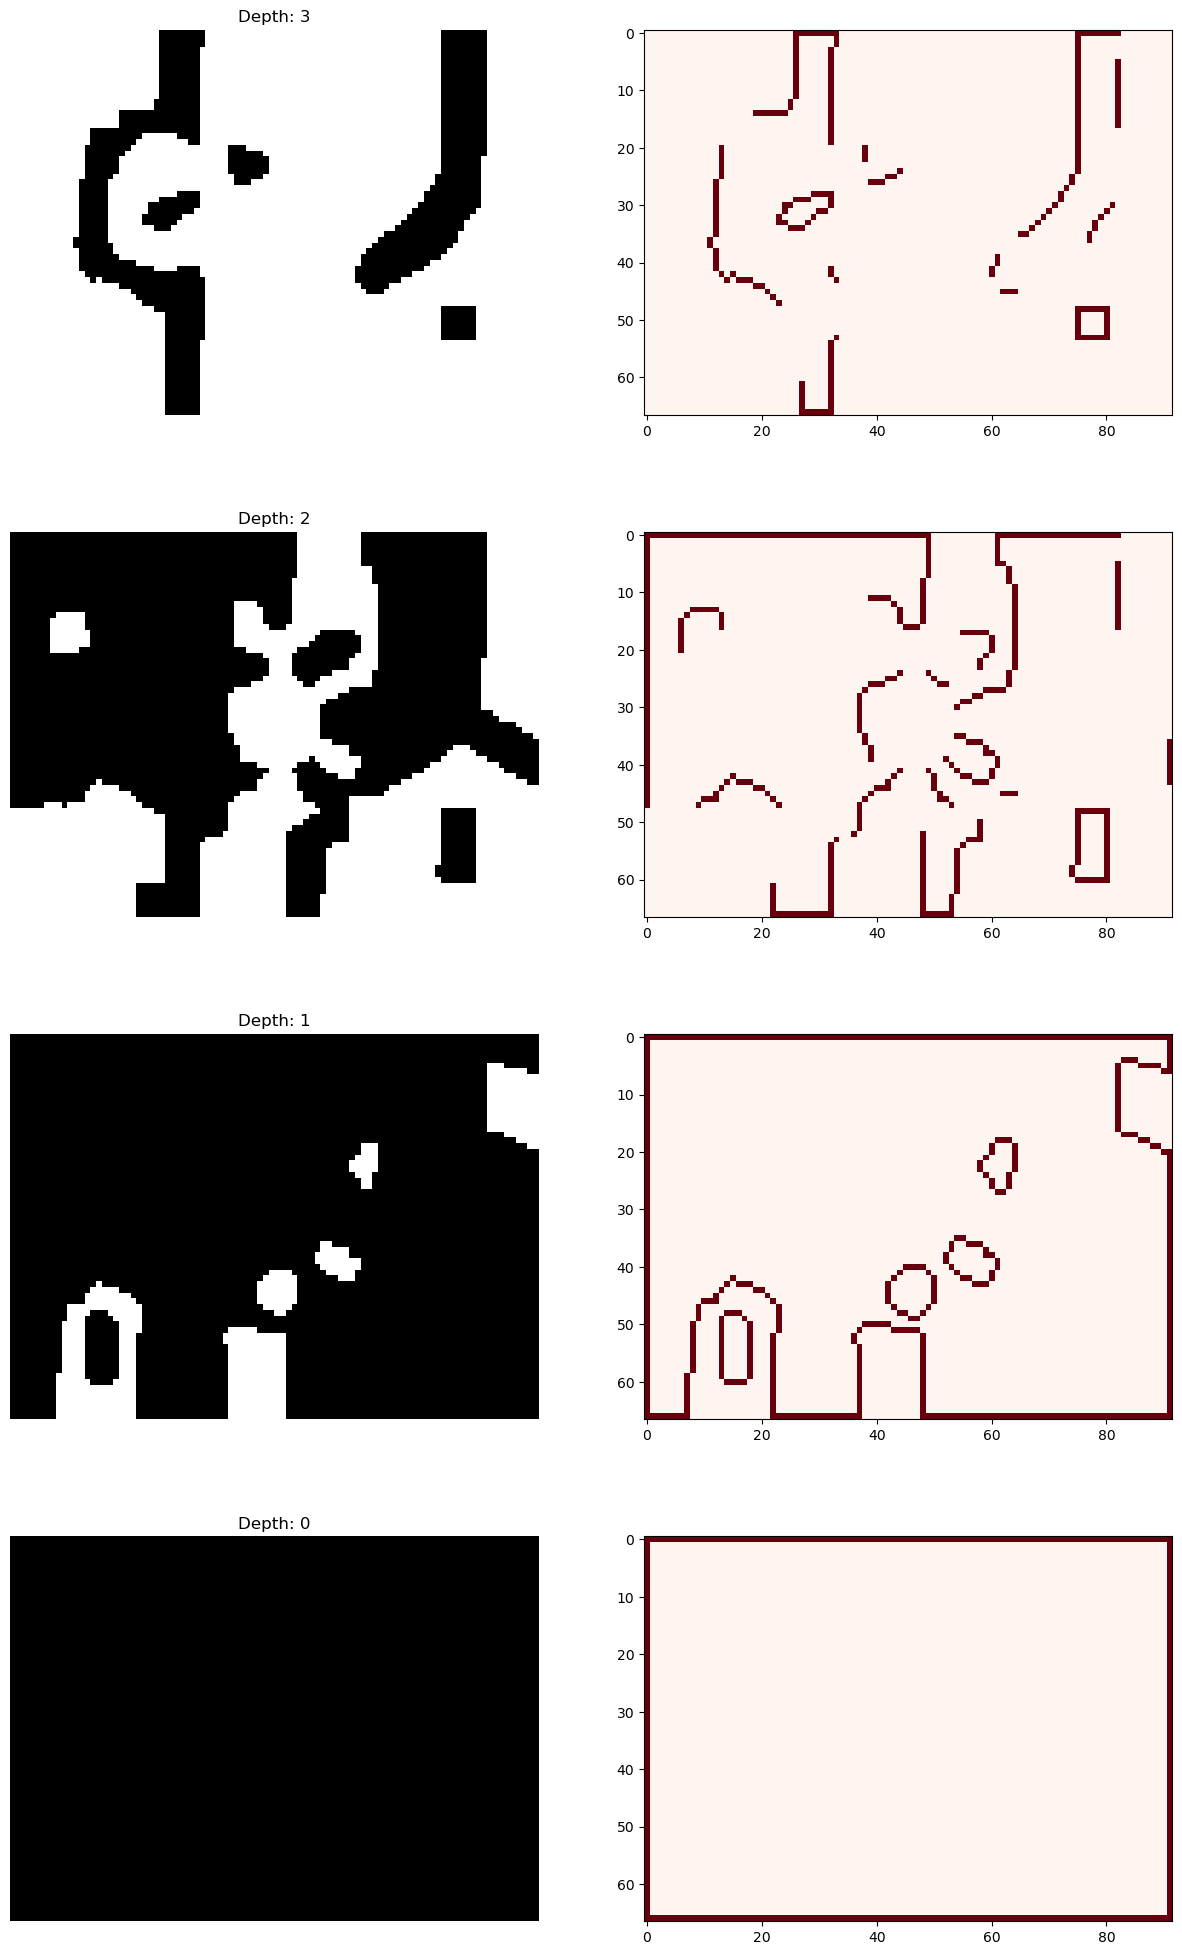

In [63]:
from itertools import chain


countors = mmcfilters.Attribute.extractCountors(tos)

def plotImageBin(nodes_by_depth, num_rows, num_cols):
    numImagens = len(nodes_by_depth)
    fig, axes = plt.subplots(numImagens,2, figsize=(15, 25))
    for i, depth in enumerate(range(numImagens-1, -1, -1)):
        imgBin = np.zeros((num_rows, num_cols), dtype=np.uint8)
        contour_img = np.zeros((num_rows, num_cols), dtype=np.uint8)
            
        for node in nodes_by_depth[depth]:
            for p in countors[node.id]:
                row = p // num_cols
                col = p % num_cols
                contour_img[row, col] = 1  

            for p in node.pixelsOfCC():
                row = p // num_cols
                col = p % num_cols
                imgBin[row, col] = 1  

        axes[i,0].imshow(imgBin, cmap='gray_r', vmax=1, vmin=0, interpolation='nearest')
        axes[i,1].imshow(contour_img, cmap='Reds')
        axes[i,0].set_title(f'Depth: {depth}')
        axes[i,0].axis('off')
       
    plt.show()

plotImageBin(nodes_by_depth, num_rows, num_cols)

In [7]:
import pandas as pd
ok = True
trainset = ["../dat/imgTeste.png", "../dat/imgObjetos.png", "../dat/cable.png"]
for i in range(len(trainset)):
    img = cv.imread(trainset[i], cv.IMREAD_GRAYSCALE)
    (img_rows, img_cols) = img.shape
    tree = mmcfilters.MorphologicalTree(img.ravel(), img_rows, img_cols)
    features, attrs = mmcfilters.Attribute.computerBasicAttributes(tree)
    
    df2 = pd.DataFrame(attrs, columns=features)
    if( len( df2[df2.isna().any(axis=1)]  ) > 0 ):
        print(i, df2[df2.isna().any(axis=1)] )
        ok = False
    #else:
    #    display.display(df2)
if(ok):
    print("Atributos verificados, tudo ok!")

Atributos verificados, tudo ok!


In [9]:
maxtree = mmcfilters.MorphologicalTree(imgInput, num_rows, num_cols, True, 1.5)
mintree = mmcfilters.MorphologicalTree(imgInput, num_rows, num_cols, False, 1.5)
tos = mmcfilters.MorphologicalTree(imgInput, num_rows, num_cols)

filterMaxtree = mmcfilters.AttributeFilters(maxtree)
filterMintree = mmcfilters.AttributeFilters(mintree)
filterToS = mmcfilters.AttributeFilters(tos)

dic, attrs_maxtree = mmcfilters.Attribute.computerBasicAttributes(maxtree)
dic, attrs_mintree = mmcfilters.Attribute.computerBasicAttributes(mintree)
dic, attrs_tos = mmcfilters.Attribute.computerBasicAttributes(tos)
dic

{'AREA': 0,
 'VOLUME': 1,
 'LEVEL': 2,
 'MEAN_LEVEL': 3,
 'VARIANCE_LEVEL': 4,
 'STANDARD_DEVIATION': 5,
 'BOX_WIDTH': 6,
 'BOX_HEIGHT': 7,
 'RECTANGULARITY': 8,
 'RATIO_WH': 9,
 'CENTRAL_MOMENT_20': 10,
 'CENTRAL_MOMENT_02': 11,
 'CENTRAL_MOMENT_11': 12,
 'CENTRAL_MOMENT_30': 13,
 'CENTRAL_MOMENT_03': 14,
 'CENTRAL_MOMENT_21': 15,
 'CENTRAL_MOMENT_12': 16,
 'ORIENTATION': 17,
 'LENGTH_MAJOR_AXIS': 18,
 'LENGTH_MINOR_AXIS': 19,
 'ECCENTRICITY': 20,
 'COMPACTNESS': 21,
 'HU_MOMENT_1_INERTIA': 22,
 'HU_MOMENT_2': 23,
 'HU_MOMENT_3': 24,
 'HU_MOMENT_4': 25,
 'HU_MOMENT_5': 26,
 'HU_MOMENT_6': 27,
 'HU_MOMENT_7': 28}

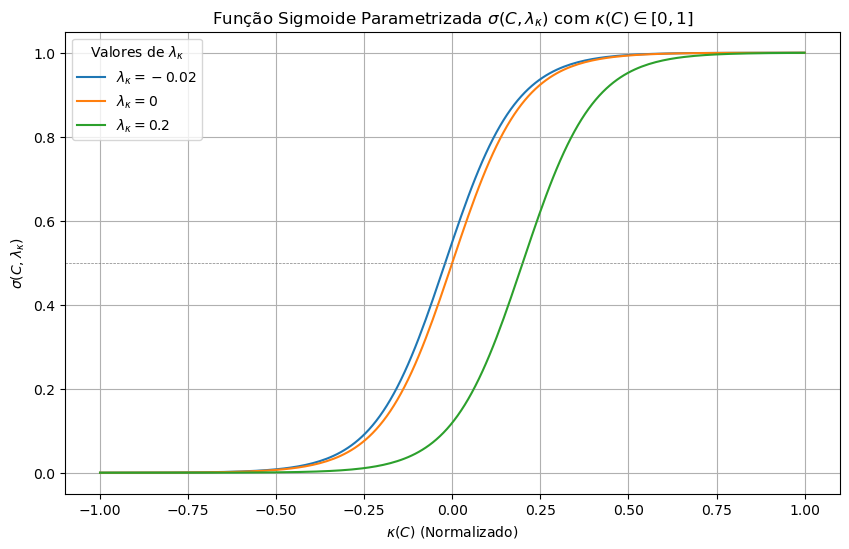

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Função sigmoide parametrizada com normalização de kappa(C) no intervalo [0, 1]
def sigmoid(kappa_C, lambda_kappa, alpha=1):
    return 1 / (1 + np.exp(-alpha * (kappa_C - lambda_kappa)))

# Valores de kappa(C) no intervalo [0, 1]
kappa_C_values = np.linspace(-1, 1, 200)  # Normalizado entre 0 e 1

# Configuração do gráfico
plt.figure(figsize=(10, 6))

# Plotando a função sigmoide para diferentes valores de lambda_kappa e alpha
lambda_kappa_values = [-0.02, 0, 0.2]  # Diferentes pontos de transição
alpha = 10  # Valor alto de alpha para uma transição mais acentuada

for lambda_kappa in lambda_kappa_values:
    sigmoid_values = sigmoid(kappa_C_values, lambda_kappa, alpha)
    plt.plot(kappa_C_values, sigmoid_values, label=f'$\\lambda_{{\\kappa}} = {lambda_kappa}$')

# Configurações do gráfico
plt.title(r'Função Sigmoide Parametrizada $\sigma(C, \lambda_{\kappa})$ com $\kappa(C) \in [0, 1]$')
plt.xlabel(r'$\kappa(C)$ (Normalizado)')
plt.ylabel(r'$\sigma(C, \lambda_{\kappa})$')
plt.axhline(y=0.5, color='gray', linestyle='--', linewidth=0.5)  # Linha de referência no meio
plt.legend(title=r'Valores de $\lambda_{\kappa}$')
plt.grid(True)
plt.show()


In [13]:
def sigmoid(kappa_C, lambda_kappa, alpha=5):
    return np.round(1 / (1 + np.exp(-alpha * (kappa_C - lambda_kappa))),3)


attr_type = dic['BOX_HEIGHT']
attr_mintree = attrs_mintree[:,attr_type]
#imgFilteredMaxtree = filterMaxtree.filteringDirectRule(att_maxtree > threshold)
list(attr_mintree), list(sigmoid(attr_mintree, 100))

/var/folders/h6/kz2mdlj914bcc1zdyjcl57zw0000gn/T/ipykernel_47503/2869295772.py:2: RuntimeWarning: overflow encountered in exp
  return np.round(1 / (1 + np.exp(-alpha * (kappa_C - lambda_kappa))),3)


([500.0, 478.0, 478.0, 478.0, 97.0, 68.0, 23.0, 200.0, 114.0, 183.0],
 [1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0])

In [73]:
from PrettyPrint import PrettyPrintTree
from colorama import Fore, Back
printTree = PrettyPrintTree(
    lambda node: node.children,
#    lambda node: ("id:" + str(node.id) + " " + str(node.isMaxtree)[0], "level:" + str(node.level) + " (" + str(node.residue) + ")", "|cnps|:" + str(len(node.cnps))  ), 
    lambda node: ("id:" + str(node.id) ), 
    color=Back.BLACK + Fore.WHITE
)

In [75]:
printTree(tos.root)

sum=0
for node in tos.listNodes:
    sum += len(node.cnps)
sum, (num_rows * num_cols)

                                                                              id:0 
  ┌──────┬─────────┬──────────┬──────────┬───────────┬───────┬───────────┬─────┴─────┬───────┬───────────────────────────┬───────────────────────────┬───────┐
 id:1   id:2      id:3       id:6       id:8       id:11   id:12       id:13       id:16   id:17                       id:18                       id:28   id:29 
                ┌──┴───┐      |      ┌───┴───┐                       ┌───┴───┐                       ┌───────┬───────────┼───────────┬───────┐               |   
               id:4   id:5   id:7   id:9   id:10                   id:14   id:15                   id:19   id:20       id:22       id:25   id:26           id:30 
                                                                                                             |       ┌───┴───┐               |               |   
                                                                                                           id

(6164, 6164)

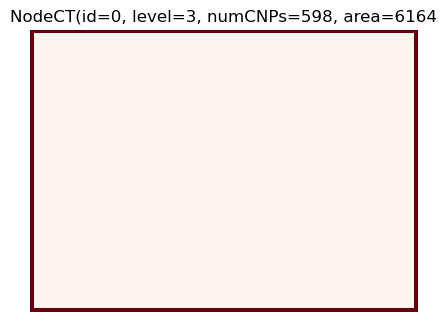

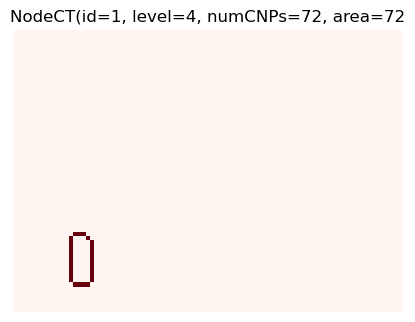

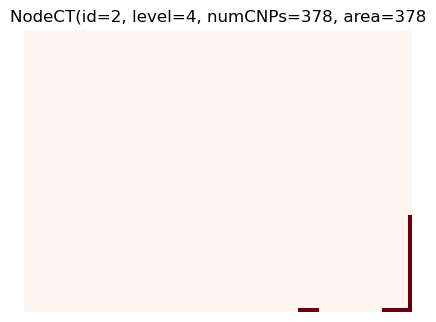

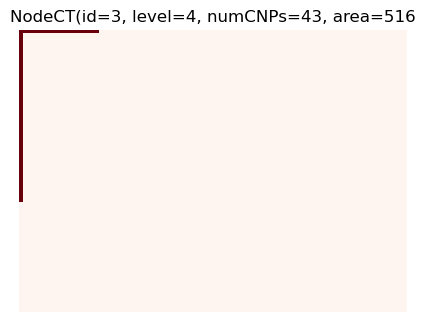

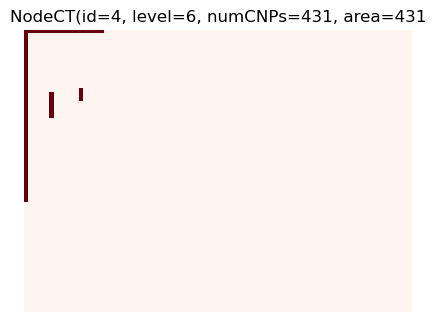

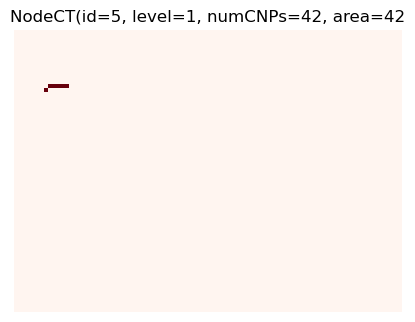

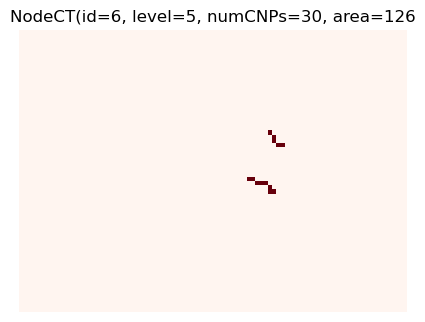

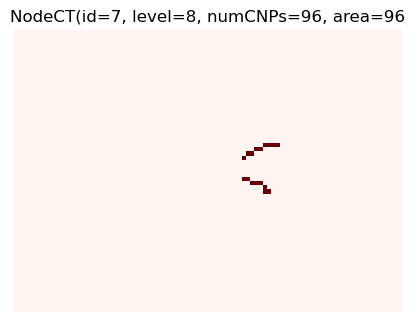

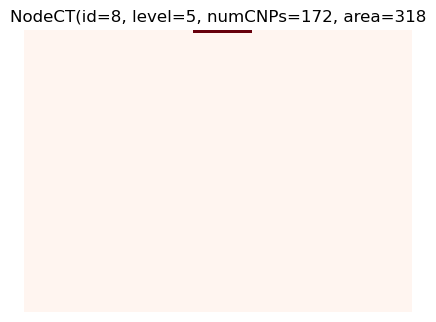

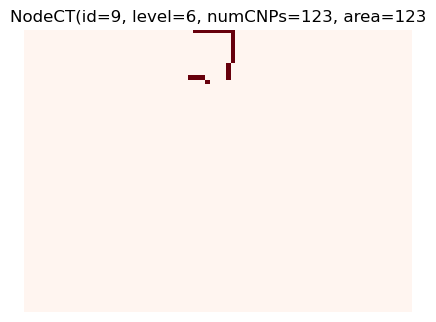

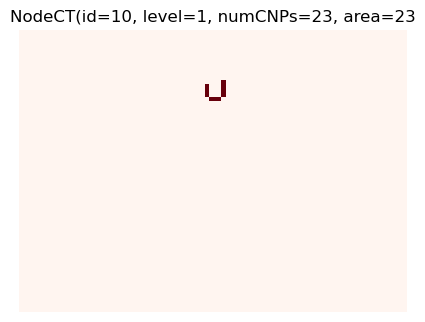

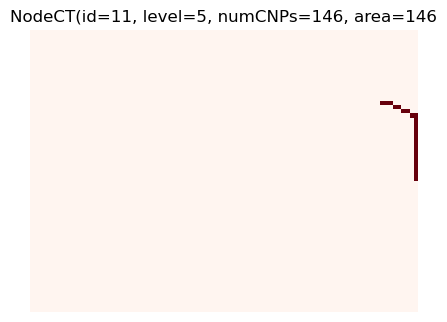

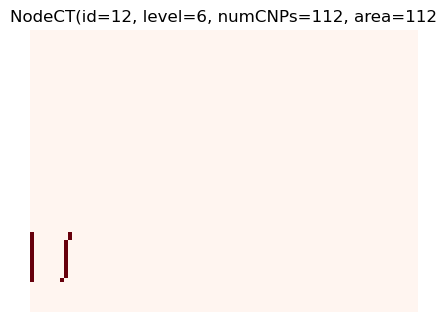

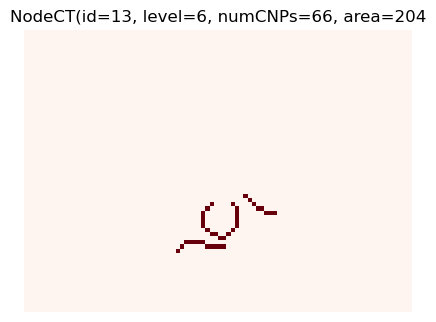

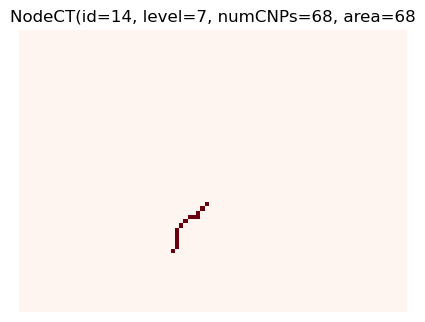

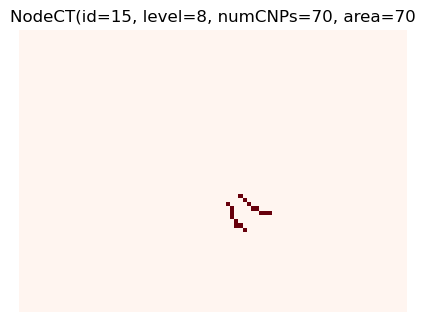

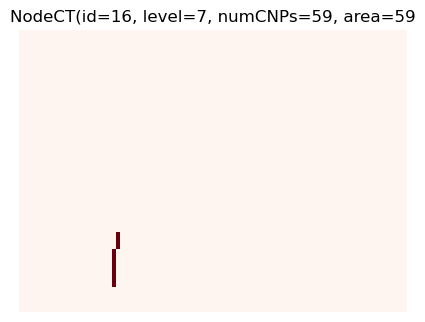

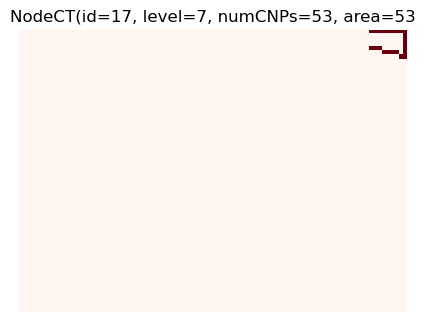

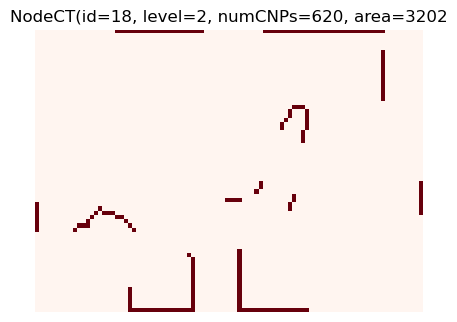

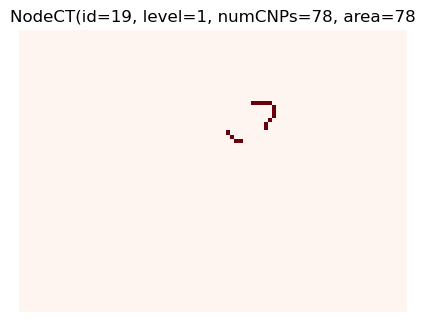

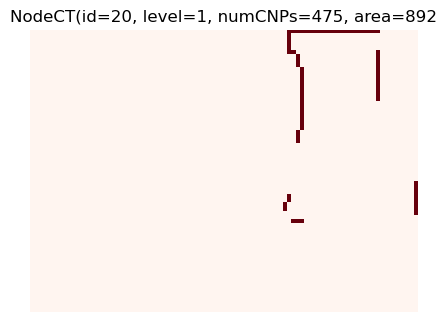

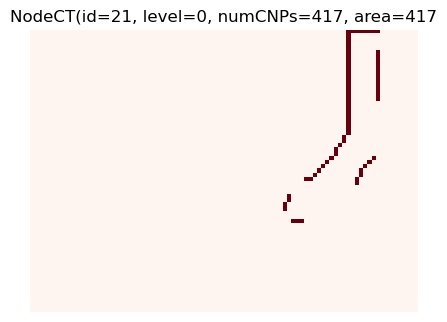

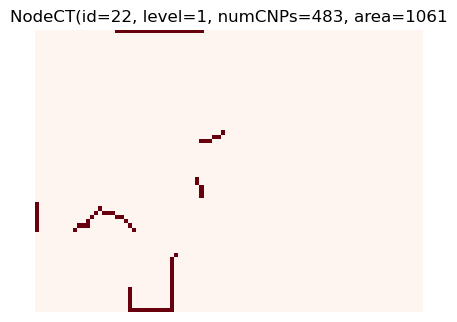

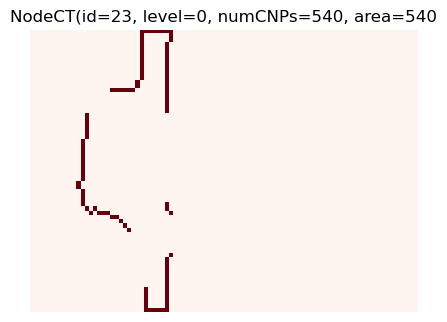

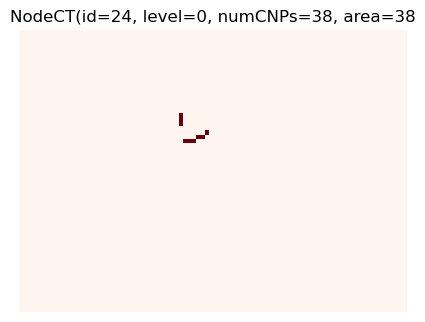

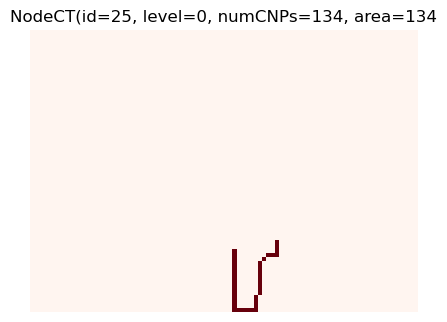

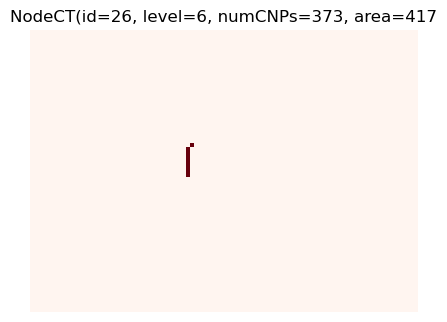

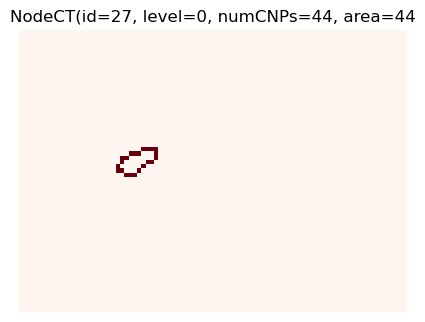

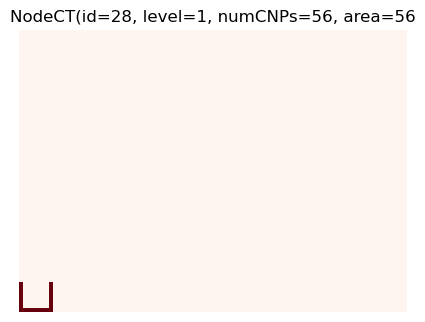

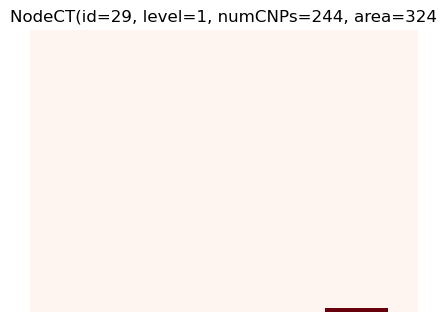

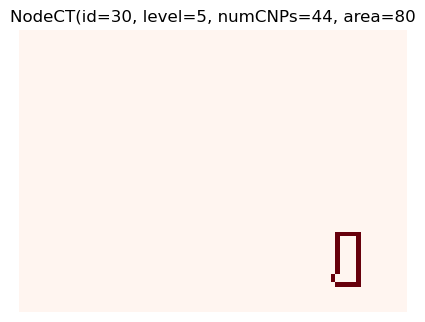

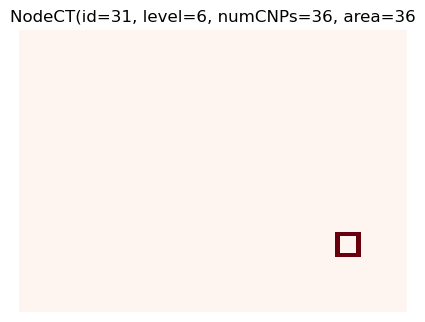

In [79]:
def plotCountors(pixels, node, num_rows, num_cols):
    contour_img = np.zeros((num_rows, num_cols), dtype=np.uint8)
    
    for p in pixels:
        row = p // num_cols
        col = p % num_cols
        contour_img[row, col] = 255  
    
    # Plotar com matplotlib
    plt.figure(figsize=(5, 5))
    plt.imshow(contour_img, cmap='Reds')
    plt.title(node)
    plt.axis('off')
    plt.show()

countors = mmcfilters.Attribute.extractCountors(tos)
nodes = tos.listNodes
for node in nodes:
    plotCountors(countors[node.id], node, num_rows, num_cols)

In [10]:
printTree(maxtree.root)
sum=0
for node in maxtree.listNodes:
    sum += len(node.cnps)
sum, (num_rows * num_cols)

                                                 ('id:0 F', 'level:38 (38)', '|cnps|:6821') 
                                                                     |
                                                  ('id:1 T', 'level:39 (1)', '|cnps|:421') 
                                                                     |
                                                ('id:2 T', 'level:54 (15)', '|cnps|:18082') 
                                                                     |
                                                 ('id:3 T', 'level:72 (18)', '|cnps|:8929') 
                                                                     |
                                                 ('id:4 T', 'level:78 (6)', '|cnps|:71014') 
                      ┌──────────────────────────────────────────────┼──────────────────────────────────────────────┐
 ('id:5 T', 'level:126 (48)', '|cnps|:17592')   ('id:6 T', 'level:126 (48)', '|cnps|:24901')   ('id:7 T', 'level:161 (83)', '|cnps|:13

(250000, 250000)

In [11]:
printTree(mintree.root)
sum=0
for node in mintree.listNodes:
    sum += len(node.cnps)
sum, (num_rows * num_cols)

                                                                                                                        ('id:0 F', 'level:203 (203)', '|cnps|:89121') 
                                                                              ┌───────────────────────────────────────────────────────────────┴────────────────┬──────────────────────────────────────────────┐
                                                         ('id:1 F', 'level:161 (42)', '|cnps|:13119')                                     ('id:3 F', 'level:126 (77)', '|cnps|:24901')   ('id:6 F', 'level:54 (149)', '|cnps|:15485') 
                                            ┌─────────────────────────────────┴──────────────────────────────────┐                                             |                                                                      
                       ('id:2 F', 'level:126 (35)', '|cnps|:17592')                         ('id:7 F', 'level:54 (107)', '|cnps|:2597')    ('id:5 F', 'level:72 (54

(250000, 250000)

Text(0.5, 1.0, 'attribute filter (tos)')

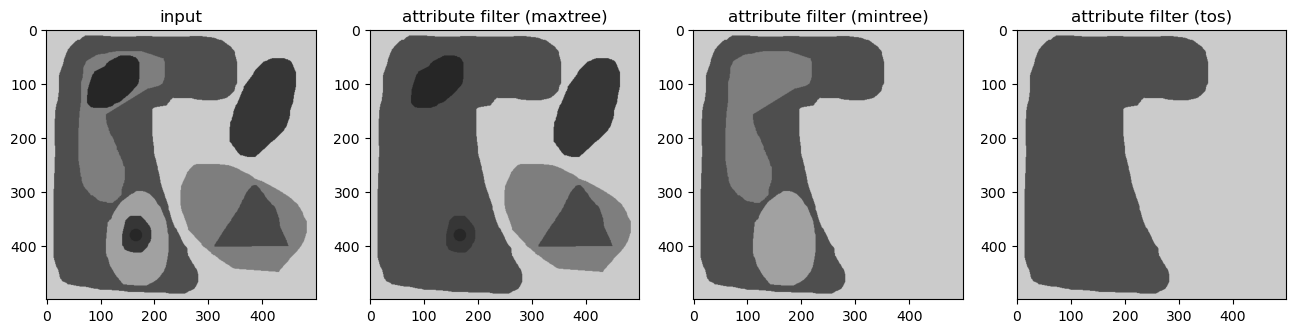

In [21]:
attr_type = dic['BOX_HEIGHT']
threshold = 400

att_maxtree = attrs_maxtree[:,attr_type]
att_mintree = attrs_mintree[:,attr_type]
att_tos = attrs_tos[:,attr_type]

imgFilteredMaxtree = filterMaxtree.filteringDirectRule(att_maxtree > threshold)
imgFilteredMintree = filterMintree.filteringDirectRule(att_mintree > threshold)
imgFilteredToS = filterToS.filteringDirectRule(att_tos > threshold)

plt.subplot(1,4, 1)
plt.imshow(imgInput, cmap='gray', vmax=255, vmin=0)
plt.title('input')

plt.subplot(1,4, 2)
plt.imshow(imgFilteredMaxtree.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('attribute filter (maxtree)')

plt.subplot(1,4, 3)
plt.imshow(imgFilteredMintree.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('attribute filter (mintree)')

plt.subplot(1,4, 4)
plt.imshow(imgFilteredToS.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('attribute filter (tos)')

Text(0.5, 1.0, 'attribute filter (tos)')

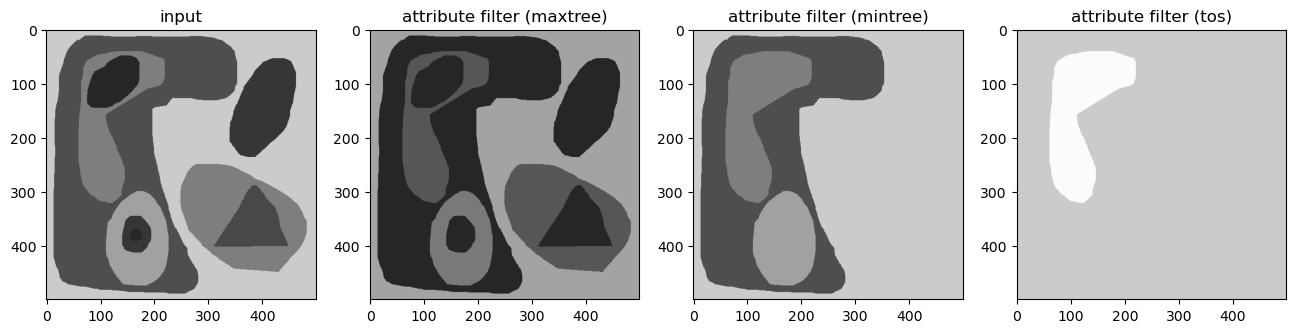

In [21]:
attr_type = dic['HU_MOMENT_1_INERTIA']
threshold = 0.2

att_maxtree = attrs_maxtree[:,attr_type]
att_mintree = attrs_mintree[:,attr_type]
att_tos = attrs_tos[:,attr_type]

imgFilteredMaxtree = filterMaxtree.filteringSubtractiveRule(att_maxtree > threshold)
imgFilteredMintree = filterMintree.filteringSubtractiveRule(att_mintree > threshold)
imgFilteredToS = filterToS.filteringSubtractiveRule(att_tos > threshold)

plt.subplot(1,4, 1)
plt.imshow(imgInput, cmap='gray', vmax=255, vmin=0)
plt.title('input')

plt.subplot(1,4, 2)
plt.imshow(imgFilteredMaxtree.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('attribute filter (maxtree)')

plt.subplot(1,4, 3)
plt.imshow(imgFilteredMintree.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('attribute filter (mintree)')

plt.subplot(1,4, 4)
plt.imshow(imgFilteredToS.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('attribute filter (tos)')

Text(0.5, 1.0, 'negative residues')

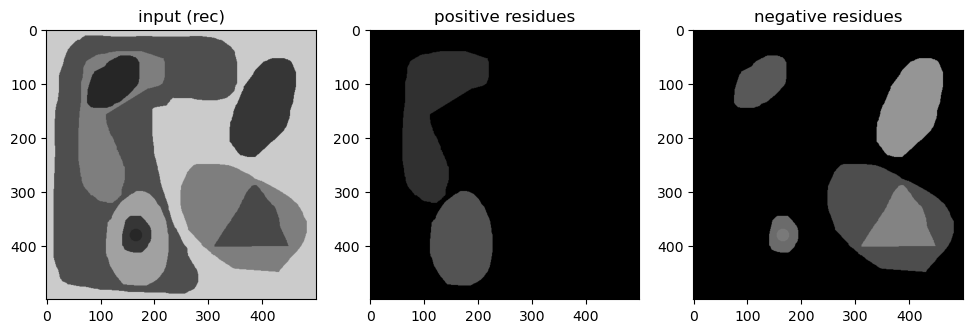

In [23]:
attr_type = dic['BOX_HEIGHT']
max_threshold = 300
attr_tos = attrs_tos[:,attr_type]
deltaMSER=5
primitives = mmcfilters.AttributeOpeningPrimitivesFamily(tos, attr_tos, max_threshold)

rtree = mmcfilters.ResidualTree(primitives)
imgRest = primitives.restOfImage
imgRec = rtree.reconstruction()
imgPos = rtree.getPositiveResidues()
imgNeg = rtree.getNegativeResidues()

plt.subplot(1,4, 1)
plt.imshow(imgRec.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('input (rec)')

plt.subplot(1,4, 2)
plt.imshow(imgPos.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('positive residues')

plt.subplot(1,4, 3)
plt.imshow(imgNeg.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('negative residues')


Text(0.5, 1.0, 'residual filter')

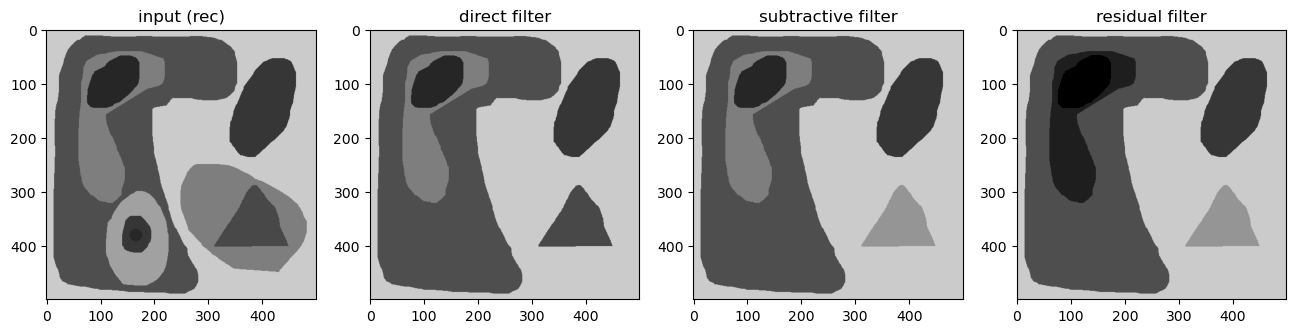

In [25]:
attr_type = dic['HU_MOMENT_1_INERTIA']
threshold = 0.18
att_tos = attrs_tos[:,attr_type]

filterToS = mmcfilters.AttributeFilters(tos)
imgAttrFilter = filterToS.filteringDirectRule(att_tos > threshold)
imgAttrSub = filterToS.filteringSubtractiveRule(att_tos > threshold)

rtree = mmcfilters.ResidualTree(primitives)
imgResFilter = rtree.filtering(att_tos > threshold)

imgRec = rtree.reconstruction()

plt.subplot(1,4, 1)
plt.imshow(imgRec.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('input (rec)')

plt.subplot(1,4, 2)
plt.imshow(imgAttrFilter.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('direct filter')

plt.subplot(1,4, 3)
plt.imshow(imgAttrSub.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('subtractive filter')


plt.subplot(1,4, 4)
plt.imshow(imgResFilter.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('residual filter')
